# 从零实现 Transformer 架构

本 Notebook 基于论文 *"Attention Is All You Need"* (Vaswani et al., 2017)，使用 PyTorch 从零实现一个完整的 Transformer 架构。

先来看一眼论文中这个经典的架构图

兔兔：太可怕了！怎么这么复杂！！
猪猪：没关系，我们现在还不用全部弄明白，先只是看一眼啦，但是学完这个课程，你就可以有底气了：切，小小transformer

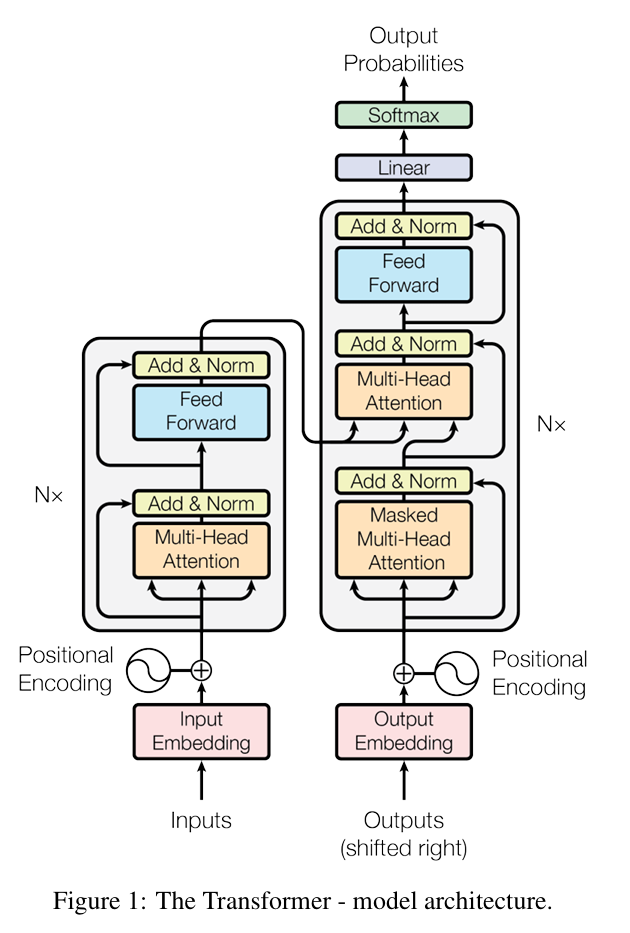

## 整体架构

```
输入序列 → [Embedding + Positional Encoding] → Encoder × N → Memory
目标序列 → [Embedding + Positional Encoding] → Decoder × N → Linear → Softmax → 输出
```

## 今天我们先来学习第一部分内容：Encoder

本章节核心学习内容为：

1. **Multi-Head Attention** — 多头注意力机制

    1.1. Softmax

    1.2. 注意力计算

    1.3. 多头注意力的工程实现
    
2. **Position-wise Feed Forward Network** — 逐位置前馈网络
3. **Positional Encoding** — 位置编码

兔兔：看不懂

猪猪：没事，饭要一口一口吃，我们一个个来逐步攻破

我们先学会第一个重要的函数：Softmax

# S1-1 第一节 Softmax

惯例，我们先导入一些必要的库，最重要的就是这个torch库

In [1]:
import math
import torch
import torch.nn as nn # nerual network

我们来看看pytorch有没有安装成功

In [2]:
print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


PyTorch version: 2.9.1+cpu
Using device: cpu


接下来我们来先创建一个输入：

记住，我们要用函数的思维去理解所谓“模型”

那在最最最最最开始，怎么先把一句话变成计算机能够处理的数字？

假设我们有一句话：I love tutu

最简单的想法就是直接给这个句子分配一个数字，比如 I love tutu = 1

这样的话如果有一个新的句子 I love zhuzhu， 就可能有 I love zhuzhu = 2

但是这个方法有个问题：这里两个句子明明都有I love，但却没有把这种相似性表现出来。

聪明的你就会想到，那我不给句子分配数字，而是给每个词分配一个数字，一个句子就是一个数组。比如：

I love tutu = [1, 2, 3]

I love zhuzhu = [1, 2, 4]

你看，相似性就表现出来了。

真棒！你发明了词向量！不过实际应用中会复杂一点，一个词汇只用一个数字还是不够用的，一般是好几个数字。比如：

I = [1, 0, 0]

love = [0, 1, 0]

tutu = [0, 0, 1]

zhuzhu = [0, 0, 2]

I love tutu = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]

I love zhuzhu = [[1, 0, 0], [0, 1, 0], [0, 0, 2]]


在实际应用中，为了得到这个词向量，我们首先还要用一个工具叫做分词器（tokenizer）, 不过我们后面再来详细介绍他的实现。现在你需要知道的是：他的作用是将一句话拆分成一个个的子词（subword）。

等等，为什么是拆分成子词而不是单词？因为虽然英语的词库很大很大，但是存在词根这个概念，比如词根love，有很多衍生词汇：loves, loved, loveable, 等等。那loves就可以拆成love - s, loved可以拆成love - ed， loveable可以拆成love - able...

经过分词器后的子词一般被称为**token**

比如：

Tutu loves zhuzhu -分词器-> Tutu - love - s - zhuzhu （四个token）

假设:

Tutu = [1, 0, 0]

love = [0, 1, 0]

s = [0, 0, 1]

zhuzhu = [0, 0, 2]

那么：
Tutu loves zhuzhu = [[1, 0, 0], [0, 1, 0], [0, 0, 1], [0, 0, 2]]

---

接下来我们开始用代码实现吧，比如我们输入的句子是：

I love tutu

假设每个词汇对应的词向量长度为3（这个长度是人为设定的，实际模型常用的值如768， 1024等， 这个长度也被称为Embedding Size 或者 Hidden dimension等， 常见符号为d_model， d_hid， d_emb甚至dim等）

我们使用torch.randn来随机生成这些数字：

（Batch_size 一般代表一次性处理的样本数，也就是多少句话，我们这里只有一句话，就是1）

（seq_len 自然就是这个句子经过分词器之后有多少个token了）

In [18]:
x = torch.randn(1, 3, 4) # [batch_size, seq_len, d_model / feat / dim]
print(x)

tensor([[[ 0.3420, -2.1852, -0.4731,  0.3531],
         [-0.3208,  0.0147,  0.8348,  0.5834],
         [-0.6920,  1.1579,  1.4706, -0.4918]]])


上面这个x现在就代表 I love tutu了

---

> 下面这个是一个工具函数，不是Transformer架构的一部分，只是为了打印中间结果，方便兔兔一步步观察transformer的计算过程
>
> 兔兔：猪猪真贴心 

In [19]:
def print_for_tutu(*args, verbose=0):
    """
    专门用于讲解模式的打印函数。
    只有当 verbose == 2 时才会打印内容。
    """
    if verbose == 2:
        for item in args:
            if isinstance(item, str):
                item = f"  {item}  "
                # 识别字符串为标题，并添加修饰符
                print(f"{item:=^50}")
            else:
                # 打印 Tensor 或其他对象内容
                print(item)
        # 组与组之间打印一个换行，保持视界清晰
        print("")

---


好啦，我们可以步入正题了

现在我们先实现 Softmax这个函数的公式, 其中$x$ 是输入， $K$ 代表元素的总个数

$$ \text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{K} e^{x_j}} $$

实际实现的时候， 因为考虑e^x是指数函数很容易变得很大， 为了防止数值溢出，一般会减去输入中的最大值来让输入的值尽可能小一点（x为负值时，e^x取值范围为（0, 1) ）：

$$ \text{Softmax}(x_i) = \frac{e^{x_i - M}}{\sum_{j=1}^{K} e^{x_j - M}} \quad \text{其中} \quad M = \max(x) $$

In [20]:
def tutu_softmax(x, verbose=0):
    """
    实现 Softmax 函数
    x: 输入张量，通常形状为 (batch_size, seq_len, feat_dim）) 或 (batch_size, num_heads, seq_len, head_dim）)
    """
    # 1. 为了数值稳定性，减去最后一个维度上的最大值
    # keepdim=True 保证减法时的广播机制正确
    x_max = torch.max(x, dim=-1, keepdim=True).values
    print_for_tutu("x", x, "x_max", x_max, verbose=verbose)

    # 防止爆精度，参考e^x函数图像，x太大了会指数爆炸，
    x = x - x_max
    print_for_tutu("x = x - x_max", x, verbose=verbose)


    exp_x = torch.exp(x)
    print_for_tutu("exp_x", exp_x, verbose=verbose)

    sum_exp_x = torch.sum(exp_x, dim=-1, keepdim=True)
    print_for_tutu("sum_exp_x", sum_exp_x, verbose=verbose)


    ret = exp_x / sum_exp_x
    print_for_tutu("最终 Softmax 结果", ret, verbose=verbose)
    
    return ret

In [21]:
# keep_dim = True: x_max.shape = (1, 3, 1)
# keep_dim = False: x_max.shape = (1, 3)

x_out = tutu_softmax(x, verbose=2)

======================  x  =======================
tensor([[[ 0.3420, -2.1852, -0.4731,  0.3531],
         [-0.3208,  0.0147,  0.8348,  0.5834],
         [-0.6920,  1.1579,  1.4706, -0.4918]]])
====================  x_max  =====================
tensor([[[0.3531],
         [0.8348],
         [1.4706]]])

================  x = x - x_max  =================
tensor([[[-0.0111, -2.5384, -0.8262,  0.0000],
         [-1.1556, -0.8202,  0.0000, -0.2514],
         [-2.1627, -0.3127,  0.0000, -1.9624]]])

====================  exp_x  =====================
tensor([[[0.9890, 0.0790, 0.4377, 1.0000],
         [0.3149, 0.4403, 1.0000, 0.7777],
         [0.1150, 0.7315, 1.0000, 0.1405]]])

==================  sum_exp_x  ===================
tensor([[[2.5057],
         [2.5329],
         [1.9870]]])

================  最终 Softmax 结果  =================
tensor([[[0.3947, 0.0315, 0.1747, 0.3991],
         [0.1243, 0.1739, 0.3948, 0.3070],
         [0.0579, 0.3681, 0.5033, 0.0707]]])



🎉🎉🎉 恭喜，现在我们完成了一个重要函数：Softmax的实现！ 🎉🎉🎉

In [22]:
# 我们可以再探索一些极端值，比如 -Inf, Inf 会怎么被处理？
inf = torch.inf
a = torch.tensor([[[inf, 0, 1], 
                   [-inf, 0, 1], 
                   [0, 0, 1]]])

# 观察结果
res = tutu_softmax(a, verbose=2)

======================  x  =======================
tensor([[[inf, 0., 1.],
         [-inf, 0., 1.],
         [0., 0., 1.]]])
====================  x_max  =====================
tensor([[[inf],
         [1.],
         [1.]]])

================  x = x - x_max  =================
tensor([[[nan, -inf, -inf],
         [-inf, -1.,  0.],
         [-1., -1.,  0.]]])

====================  exp_x  =====================
tensor([[[   nan, 0.0000, 0.0000],
         [0.0000, 0.3679, 1.0000],
         [0.3679, 0.3679, 1.0000]]])

==================  sum_exp_x  ===================
tensor([[[   nan],
         [1.3679],
         [1.7358]]])

================  最终 Softmax 结果  =================
tensor([[[   nan,    nan,    nan],
         [0.0000, 0.2689, 0.7311],
         [0.2119, 0.2119, 0.5761]]])



#### * 在这里写下你的观察和思考：


---
（在这里写）

In [23]:
print(x)

tensor([[[ 0.3420, -2.1852, -0.4731,  0.3531],
         [-0.3208,  0.0147,  0.8348,  0.5834],
         [-0.6920,  1.1579,  1.4706, -0.4918]]])


In [27]:
q = torch.randn(1,3,3)
q_x = torch.matmul(q,x)
print(q)
print(q_x)

tensor([[[-0.1644,  0.7281, -0.9264],
         [ 0.2841,  1.0822,  3.0389],
         [ 0.4828,  0.8257,  0.8642]]])
tensor([[[ 0.3513, -0.7027, -0.6767,  0.8223],
         [-2.3530,  2.9138,  5.2381, -0.7628],
         [-0.6977, -0.0424,  1.7317,  0.2272]]])


In [28]:
k= torch.randn(1,3,3)
k_x = torch.matmul(k,x)
print(k_x)

tensor([[[ 0.2960, -2.3471, -0.2660,  1.1180],
         [-0.6732,  1.6828,  1.4115,  0.2315],
         [ 0.6591, -1.5415, -1.3095,  0.7393]]])


In [29]:
v= torch.randn(1,3,3)
v_x = torch.matmul(v,x)
print(v_x)

tensor([[[ 0.5660, -2.8413, -0.9232,  0.3307],
         [-0.3100, -1.7946,  1.0239, -0.0498],
         [ 0.8203, -3.1244, -1.4001,  1.4389]]])


In [36]:
k_x_reverse = k_x.transpose(-1,-2)
print(q_x)
print(k_x_reverse)

tensor([[[ 0.3513, -0.7027, -0.6767,  0.8223],
         [-2.3530,  2.9138,  5.2381, -0.7628],
         [-0.6977, -0.0424,  1.7317,  0.2272]]])
tensor([[[ 0.2960, -0.6732,  0.6591],
         [-2.3471,  1.6828, -1.5415],
         [-0.2660,  1.4115, -1.3095],
         [ 1.1180,  0.2315,  0.7393]]])


In [38]:
attention_score=torch.matmul(q_x,k_x_reverse)
print(attention_score)

tensor([[[  2.8528,  -2.1839,   2.8090],
         [ -9.7819,  13.7045, -13.4657],
         [ -0.3137,   2.8954,  -2.4942]]])


In [39]:
attention_score=tutu_softmax(attention_score)
print(attention_score)

tensor([[[5.0927e-01, 3.3078e-03, 4.8743e-01],
         [6.3097e-11, 1.0000e+00, 1.5853e-12],
         [3.8658e-02, 9.5697e-01, 4.3674e-03]]])


[[1, 1, 0], [0, 0, 1], [0, 0, 0]]


In [40]:
print(v_x)

tensor([[[ 0.5660, -2.8413, -0.9232,  0.3307],
         [-0.3100, -1.7946,  1.0239, -0.0498],
         [ 0.8203, -3.1244, -1.4001,  1.4389]]])


In [43]:
v_x_reverse = v_x.transpose(-1,-2)
print(v_x_reverse)
attention = torch.matmul(attention_score,v_x)
print(attention)

tensor([[[ 0.5660, -0.3100,  0.8203],
         [-2.8413, -1.7946, -3.1244],
         [-0.9232,  1.0239, -1.4001],
         [ 0.3307, -0.0498,  1.4389]]])
tensor([[[ 0.6871, -2.9759, -1.1492,  0.8696],
         [-0.3100, -1.7946,  1.0239, -0.0498],
         [-0.2712, -1.8409,  0.9380, -0.0286]]])
